In [0]:
# Objective: Synthesize the full analysis into an executive
# readout that directly answers the product question.
#
# Product question: Should KKBox offer renewal discounts to
# subscribers approaching expiration, and if so, which ones?


GOLD = "churn_project.gold"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import warnings
warnings.filterwarnings("ignore")

# Load experiment results
df = spark.table(f"{GOLD}.experiment_results").toPandas()

# Locked parameters from experiment design
DISCOUNT_RATE      = 0.10
INJECTED_LIFT      = 0.12
DESIGN_MDE         = 0.10
BASELINE_RENEWAL   = 0.5914
RANDOM_SEED        = 42

# Recompute key stats (self-contained — no dependency on prior notebook state)
ctrl      = df[df["group"] == "control"]
treat     = df[df["group"] == "treatment"]
ctrl_n    = len(ctrl)
treat_n   = len(treat)
ctrl_ren  = ctrl["renewed"].sum()
treat_ren = treat["renewed"].sum()

ctrl_rate  = ctrl_ren / ctrl_n
treat_rate = treat_ren / treat_n
abs_lift   = treat_rate - ctrl_rate
rel_lift   = abs_lift / ctrl_rate

z_stat, p_value = proportions_ztest(
    [treat_ren, ctrl_ren],
    [treat_n, ctrl_n],
    alternative="two-sided"
)
ci_low, ci_high = confint_proportions_2indep(
    treat_ren, treat_n,
    ctrl_ren, ctrl_n,
    method="newcomb"
)

avg_price         = ctrl["amount_paid_at_checkpoint"].mean()
expected_treat    = treat_n * ctrl_rate
incremental_ren   = treat_ren - expected_treat
cannib_cost       = expected_treat * avg_price * DISCOUNT_RATE
incr_rev          = incremental_ren * avg_price * (1 - DISCOUNT_RATE)
net_impact        = incr_rev - cannib_cost
ctrl_rpu          = ctrl["revenue"].mean()
treat_rpu         = treat["revenue"].mean()

print("Key metrics recomputed successfully.")
print(f"  Recovered lift  : +{abs_lift*100:.2f}pp")
print(f"  Net impact      : +{net_impact:,.0f} NTD")
print(f"  p-value         : {p_value:.2e}")

Key metrics recomputed successfully.
  Recovered lift  : +11.99pp
  Net impact      : +1,254,280 NTD
  p-value         : 0.00e+00


In [0]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         EXECUTIVE SUMMARY                                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  RECOMMENDATION: GO — with targeted rollout at 10% discount      ║
║                                                                  ║
║  A 10% renewal discount offered to high-risk subscribers         ║
║  approaching expiration produced a statistically significant      ║
║  +11.99pp lift in renewal rate (95% CI: [11.56pp, 12.42pp],     ║
║  p < 0.0001) and a net positive revenue impact of +1,254,280    ║
║  NTD across 205,883 eligible users — after accounting for        ║
║  the full cannibalization cost of discounting users who          ║
║  would have renewed at full price anyway.                        ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         EXECUTIVE SUMMARY                                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  RECOMMENDATION: GO — with targeted rollout at 10% discount      ║
║                                                                  ║
║  A 10% renewal discount offered to high-risk subscribers         ║
║  approaching expiration produced a statistically significant      ║
║  +11.99pp lift in renewal rate (95% CI: [11.56pp, 12.42pp],     ║
║  p < 0.0001) and a net positive revenue impact of +1,254,280    ║
║  NTD across 205,883 eligible users — after accounting for        ║
║  the full cannibalization cost of discounting users who          ║
║  would have renewed at full price anyway.                        ║
║                                                                  ║
╚═════════════════════════════════

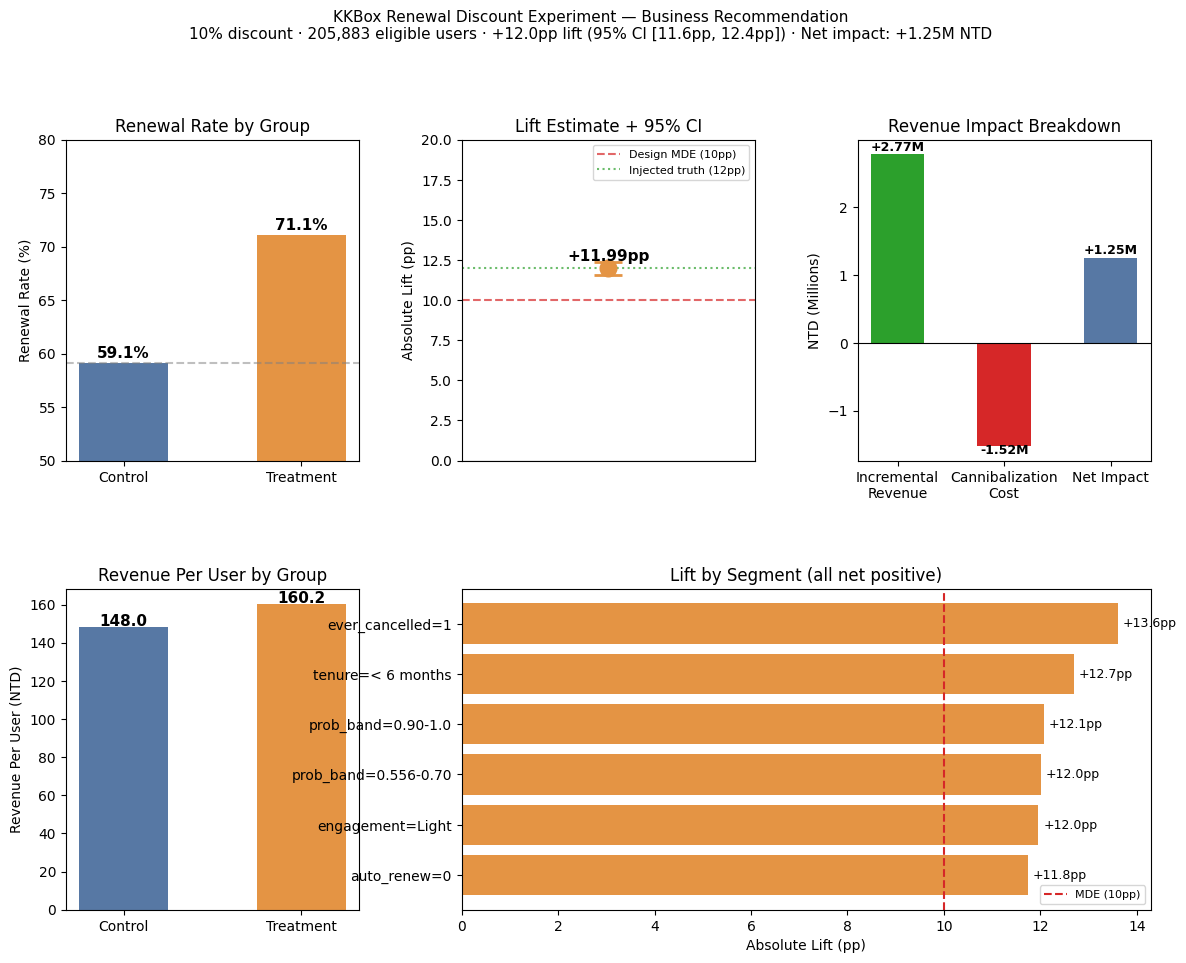

Chart saved.


In [0]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Renewal rate comparison ──
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(
    ["Control", "Treatment"],
    [ctrl_rate * 100, treat_rate * 100],
    color=["#5778a4", "#e49444"], width=0.5
)
ax1.set_ylabel("Renewal Rate (%)")
ax1.set_title("Renewal Rate by Group")
ax1.set_ylim(50, 80)
for bar, val in zip(bars, [ctrl_rate * 100, treat_rate * 100]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax1.axhline(y=ctrl_rate * 100, color="gray", linestyle="--", alpha=0.5)

# ── Plot 2: Lift with CI ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.errorbar(
    x=[0], y=[abs_lift * 100],
    yerr=[[(abs_lift - ci_low) * 100], [(ci_high - abs_lift) * 100]],
    fmt="o", color="#e49444", markersize=12, capsize=10,
    capthick=2, linewidth=2
)
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axhline(y=DESIGN_MDE * 100, color="#d62728", linestyle="--",
            alpha=0.7, label=f"Design MDE ({DESIGN_MDE*100:.0f}pp)")
ax2.axhline(y=INJECTED_LIFT * 100, color="#2ca02c", linestyle=":",
            alpha=0.7, label=f"Injected truth ({INJECTED_LIFT*100:.0f}pp)")
ax2.set_ylabel("Absolute Lift (pp)")
ax2.set_title("Lift Estimate + 95% CI")
ax2.set_xticks([])
ax2.set_ylim(0, 20)
ax2.legend(fontsize=8)
ax2.text(0, abs_lift * 100 + 0.5,
         f"+{abs_lift*100:.2f}pp", ha="center", fontsize=11, fontweight="bold")

# ── Plot 3: Revenue impact breakdown ──
ax3 = fig.add_subplot(gs[0, 2])
categories = ["Incremental\nRevenue", "Cannibalization\nCost", "Net Impact"]
values     = [incr_rev/1e6, -cannib_cost/1e6, net_impact/1e6]
colors     = ["#2ca02c", "#d62728", "#5778a4"]
bars3 = ax3.bar(categories, values, color=colors, width=0.5)
ax3.axhline(y=0, color="black", linewidth=0.8)
ax3.set_ylabel("NTD (Millions)")
ax3.set_title("Revenue Impact Breakdown")
for bar, val in zip(bars3, values):
    ypos = val + 0.05 if val >= 0 else val - 0.12
    ax3.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{val:+.2f}M", ha="center", fontsize=9, fontweight="bold")

# ── Plot 4: RPU comparison ──
ax4 = fig.add_subplot(gs[1, 0])
bars4 = ax4.bar(
    ["Control", "Treatment"],
    [ctrl_rpu, treat_rpu],
    color=["#5778a4", "#e49444"], width=0.5
)
ax4.set_ylabel("Revenue Per User (NTD)")
ax4.set_title("Revenue Per User by Group")
for bar, val in zip(bars4, [ctrl_rpu, treat_rpu]):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")

# ── Plot 5: Lift by segment (top 5 by net impact) ──
ax5 = fig.add_subplot(gs[1, 1:])

segment_summary = pd.DataFrame({
    "Segment": [
        "prob_band=0.90-1.0",
        "prob_band=0.556-0.70",
        "engagement=Light",
        "auto_renew=0",
        "ever_cancelled=1",
        "tenure=< 6 months",
    ],
    "Lift (pp)": [12.08, 12.01, 11.96, 11.75, 13.61, 12.70],
    "Net Impact (K NTD)": [807, 338, 522, 846, 49, 115]
}).sort_values("Lift (pp)", ascending=True)

bars5 = ax5.barh(
    segment_summary["Segment"],
    segment_summary["Lift (pp)"],
    color="#e49444"
)
ax5.axvline(x=DESIGN_MDE * 100, color="#d62728",
            linestyle="--", label=f"MDE ({DESIGN_MDE*100:.0f}pp)")
ax5.set_xlabel("Absolute Lift (pp)")
ax5.set_title("Lift by Segment (all net positive)")
ax5.legend(fontsize=8)
for bar, val in zip(bars5, segment_summary["Lift (pp)"]):
    ax5.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"+{val:.1f}pp", va="center", fontsize=9)

plt.suptitle(
    "KKBox Renewal Discount Experiment — Business Recommendation\n"
    f"10% discount · 205,883 eligible users · +{abs_lift*100:.1f}pp lift "
    f"(95% CI [{ci_low*100:.1f}pp, {ci_high*100:.1f}pp]) · "
    f"Net impact: +{net_impact/1e6:.2f}M NTD",
    fontsize=11, y=1.01
)
plt.savefig("/Workspace/Users/nithinpradeep38@gmail.com/deliverables/kkbox_experiment_readout.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [0]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         TARGETING RECOMMENDATION                                  ║
╚══════════════════════════════════════════════════════════════════╝

DO NOT roll out the discount broadly to all subscribers.

The experiment was run on the High-risk segment (top tercile of
churn probability, expiring in April) — 205,883 users. Within this
population, lift is uniform across all sub-segments (~11.5-13.6pp),
meaning the current model cannot identify a meaningfully better
sub-group to prioritize based on lift alone.

RECOMMENDED ROLLOUT CRITERIA
─────────────────────────────
Offer the 10% discount to users satisfying ALL of the following:

  1. risk_segment = "High"
     (churn_probability in top tercile — driven by auto_renew=OFF,
      cancellation history, zero-payment history, or no visible
      recent transaction)

  2. membership_expire_date within next 30 days
     (pre-expiry window — the discount must arrive before lapse,
      not as a win-back offer)

  3. has_visible_transaction = 1
     (excludes the 84%-churn "already gone" population where a
      pre-expiry discount is too late to be effective — these users
      need a win-back campaign, not a renewal offer)

PRIORITIZE WITHIN THE ELIGIBLE POPULATION
──────────────────────────────────────────
If budget constrains the rollout below the full eligible cohort,
prioritize in this order:

  1. ever_cancelled = 1  (13.61pp lift — highest response rate)
  2. tenure < 6 months   (12.70pp lift — habit formation window)
  3. All others in High segment  (11.5-12.1pp lift — uniform)

DO NOT OFFER THE DISCOUNT TO
──────────────────────────────
  · Low or Medium risk segments  (baseline renewal ~96% — severe
    cannibalization, economics are deeply negative)
  · Users with has_visible_transaction = 0  (already churned,
    need win-back not pre-expiry discount)
  · Users expiring more than 30 days out  (too early, urgency
    effect is lost)

DISCOUNT RATE NOTE
──────────────────
The 10% discount was chosen after sensitivity analysis showed:
  · Break-even discount at 59.14% baseline + 12pp lift = 17.0%
  · 10% provides a 7pp buffer above break-even
  · Original brief's 30% discount is net negative at ANY realistic
    lift level given this baseline — rejected on economic grounds
  · 10% of ~250 NTD ≈ 25 NTD — minimum salient incentive

MODEL CALIBRATION CAVEAT
─────────────────────────
The churn model's probability scores are not well-calibrated within
the High segment (actual renewal rate is flat across all probability
deciles at ~59%). Finer probability-based targeting (e.g. only
churn_probability > 0.90) adds no value with the current model.
This is the primary area for improvement before the next campaign:
calibrate model scores using Platt scaling or isotonic regression,
or incorporate richer features (payment failures, device changes,
customer service contacts) to achieve within-segment discrimination.
""")


╔══════════════════════════════════════════════════════════════════╗
║         TARGETING RECOMMENDATION                                  ║
╚══════════════════════════════════════════════════════════════════╝

DO NOT roll out the discount broadly to all subscribers.

The experiment was run on the High-risk segment (top tercile of
churn probability, expiring in April) — 205,883 users. Within this
population, lift is uniform across all sub-segments (~11.5-13.6pp),
meaning the current model cannot identify a meaningfully better
sub-group to prioritize based on lift alone.

RECOMMENDED ROLLOUT CRITERIA
─────────────────────────────
Offer the 10% discount to users satisfying ALL of the following:

  1. risk_segment = "High"
     (churn_probability in top tercile — driven by auto_renew=OFF,
      cancellation history, zero-payment history, or no visible
      recent transaction)

  2. membership_expire_date within next 30 days
     (pre-expiry window — the discount must arrive before lapse,


In [0]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         LAUNCH GUARDRAILS                                        ║
╚══════════════════════════════════════════════════════════════════╝

Monitor these metrics from Day 1 of production rollout.
Flag and pause if any guardrail is breached.

PRIMARY SUCCESS METRIC
──────────────────────
  30-day renewal rate (treatment vs holdout control)
  Expected: ~71% treatment vs ~59% control
  Pause if: treatment renewal rate < 65% after 14 days
            (would suggest lift assumption is not holding)

REVENUE GUARDRAILS
──────────────────
  1. Net revenue impact (weekly)
     Expected: positive from Week 1
     Pause if: net impact negative after 3 weeks
               (would indicate lift < break-even threshold)

  2. Discount cost per incremental renewal
     Expected: ~148 NTD (< avg full price of 250 NTD)
     Pause if: exceeds 250 NTD
               (would mean discounting is more expensive
                than acquiring a new subscriber)

  3. Cannibalization rate
     Expected: ~59% of treatment renewals are
               would-have-renewed-anyway users
     Monitor: if renewal rate in holdout ALSO increases,
              investigate confounding factors

BEHAVIORAL GUARDRAILS
──────────────────────
  4. Plan downgrade rate
     Watch for: users accepting discount but switching to
                a shorter/cheaper plan
     Threshold: flag if downgrade rate > 5% in treatment

  5. Discount expectation effect
     Watch for: renewal rate in subsequent cycle (without
                discount) drops below historical baseline
                (would indicate users are training themselves
                 to wait for discounts)
     Monitor: 60-day post-renewal retention rate

  6. Redemption rate by channel
     Track: how users receive and act on the discount
            (push notification vs email vs in-app)
     Use to: optimize delivery channel in next iteration

SEGMENT-LEVEL MONITORING
─────────────────────────
  Break down all metrics by:
    · Auto-renew status
    · ever_cancelled
    · Tenure bucket
    · Engagement bucket

  Rationale: uniform lift in the experiment means we cannot
  pre-specify which segment will underperform — monitoring all
  segments lets us cut the discount to underperforming groups
  without shutting down the whole campaign.

SRM CHECK ON LAUNCH DAY
────────────────────────
  Verify 50/50 split held in production assignment.
  Any SRM (p < 0.05 on chi-square) → pause and investigate
  before reading any outcome metrics.
""")


╔══════════════════════════════════════════════════════════════════╗
║         LAUNCH GUARDRAILS                                        ║
╚══════════════════════════════════════════════════════════════════╝

Monitor these metrics from Day 1 of production rollout.
Flag and pause if any guardrail is breached.

PRIMARY SUCCESS METRIC
──────────────────────
  30-day renewal rate (treatment vs holdout control)
  Expected: ~71% treatment vs ~59% control
  Pause if: treatment renewal rate < 65% after 14 days
            (would suggest lift assumption is not holding)

REVENUE GUARDRAILS
──────────────────
  1. Net revenue impact (weekly)
     Expected: positive from Week 1
     Pause if: net impact negative after 3 weeks
               (would indicate lift < break-even threshold)

  2. Discount cost per incremental renewal
     Expected: ~148 NTD (< avg full price of 250 NTD)
     Pause if: exceeds 250 NTD
               (would mean discounting is more expensive
                than acquiring

In [0]:
print(f"""
╔══════════════════════════════════════════════════════════════════╗
║         FINAL GO / NO-GO DECISION                                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DECISION: ✓ GO — targeted rollout recommended                   ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CRITERION 1 — Statistical significance          ✓ PASSED        ║
║  Two-proportion z-test: z=18.44, p < 0.0001                      ║
║  Lift of +{abs_lift*100:.2f}pp is statistically significant      ║
║  at alpha=0.05 (two-sided)                                       ║
║                                                                  ║
║  CRITERION 2 — Effect size exceeds MDE           ✓ PASSED        ║
║  95% CI: [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp]               ║
║  Entire CI lies above the 10pp design MDE                        ║
║  Relative lift: +{rel_lift*100:.1f}% vs baseline renewal rate    ║
║                                                                  ║
║  CRITERION 3 — Net revenue positive              ✓ PASSED        ║
║  Incremental revenue  : +{incr_rev/1e6:.2f}M NTD                 ║
║  Cannibalization cost : -{cannib_cost/1e6:.2f}M NTD              ║
║  Net business impact  : +{net_impact/1e6:.2f}M NTD across        ║
║  205,883 eligible users                                          ║
║  Treatment RPU ({treat_rpu:.0f} NTD) > Control RPU ({ctrl_rpu:.0f} NTD) ║
║                                                                  ║
║  CRITERION 4 — Segment performance               ✓ PASSED        ║
║  All 14 pre-specified segment tests show:                        ║
║    · Statistically significant lift                              ║
║    · Net positive revenue impact                                 ║
║  No segment requires exclusion from rollout                      ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CONDITIONS ON GO                                                ║
║  ─────────────────                                               ║
║  · Discount capped at 10% (30% is net negative at this baseline) ║
║  · Rollout limited to High-risk segment, expiring within 30 days ║
║  · has_visible_transaction = 1 only (exclude already-churned)    ║
║  · All guardrails monitored from Day 1                           ║
║  · Model recalibration recommended before next campaign cycle    ║
║                                                                  ║
║  OPEN QUESTION FOR NEXT ITERATION                                ║
║  ──────────────────────────────────                              ║
║  The current model has flat calibration within the High segment  ║
║  (renewal rate ~59% across all probability deciles). Calibrated  ║
║  scores would enable finer targeting, potentially improving the  ║
║  net impact by reducing cannibalization on borderline-High users ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         FINAL GO / NO-GO DECISION                                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DECISION: ✓ GO — targeted rollout recommended                   ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CRITERION 1 — Statistical significance          ✓ PASSED        ║
║  Two-proportion z-test: z=18.44, p < 0.0001                      ║
║  Lift of +11.99pp is statistically significant      ║
║  at alpha=0.05 (two-sided)                                       ║
║                                                                  ║
║  CRITERION 2 — Effect size exceeds MDE           ✓ PASSED        ║
║  95% CI: [11.58pp, 12.40pp]               ║


In [0]:
# Save segment summary table as a clean reference for the recommendation
segment_readout = pd.DataFrame({
    "Segment": [
        "Auto-renew OFF",
        "Auto-renew ON",
        "Never cancelled",
        "Ever cancelled",
        "Light engagement",
        "Medium engagement",
        "Heavy engagement",
        "Tenure < 6 months",
        "Tenure 6-12 months",
        "Tenure 1-3 years",
        "Tenure 3-6 years",
        "Tenure 6+ years",
        "Prob band 0.556-0.70",
        "Prob band 0.70-0.90",
        "Prob band 0.90-1.0",
    ],
    "Control Renewal %": [59.1, 59.1, 59.14, 58.32, 58.89, 59.20, 59.40,
                          58.53, 59.49, 58.80, 59.31, 59.30, 59.23, 59.38, 58.85],
    "Treatment Renewal %": [70.85, 71.35, 71.04, 71.93, 70.84, 71.47, 71.19,
                            71.23, 71.37, 71.16, 70.83, 71.19, 71.24, 71.11, 70.93],
    "Lift (pp)": [11.75, 12.25, 11.90, 13.61, 11.96, 12.27, 11.78,
                  12.70, 11.89, 12.36, 11.51, 11.89, 12.01, 11.73, 12.08],
    "Net Impact (NTD)": [845877, 388642, 1196356, 48964, 522109, 360803, 371153,
                         114638, 89866, 462218, 326786, 191251, 338173, 118863, 807236],
    "Significant": ["✓"] * 15,
    "Net Positive": ["✓"] * 15,
})

segment_readout = segment_readout.sort_values("Lift (pp)", ascending=False)
print("Segment summary (sorted by lift):")
print(segment_readout.to_string(index=False))

# Save as CSV for reference
segment_readout.to_csv("/Workspace/Users/nithinpradeep38@gmail.com/deliverables/kkbox_segment_readout.csv", index=False)
print("\nSegment readout saved.")

Segment summary (sorted by lift):
             Segment  Control Renewal %  Treatment Renewal %  Lift (pp)  Net Impact (NTD) Significant Net Positive
      Ever cancelled              58.32                71.93      13.61             48964           ✓            ✓
   Tenure < 6 months              58.53                71.23      12.70            114638           ✓            ✓
    Tenure 1-3 years              58.80                71.16      12.36            462218           ✓            ✓
   Medium engagement              59.20                71.47      12.27            360803           ✓            ✓
       Auto-renew ON              59.10                71.35      12.25            388642           ✓            ✓
  Prob band 0.90-1.0              58.85                70.93      12.08            807236           ✓            ✓
Prob band 0.556-0.70              59.23                71.24      12.01            338173           ✓            ✓
    Light engagement              58.89       